In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

In [4]:
# Read in SDSS data
from sdss_data.sdss_loader import load_sdss_csv
df = load_sdss_csv("sdss_data/fields/sdss_target.csv")

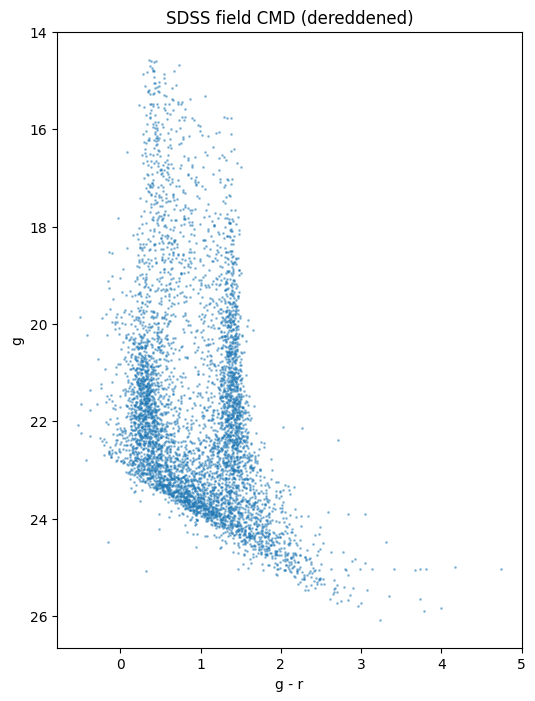

In [5]:
# Plot SDSS data on CMD without reddening as a sanity check
import matplotlib.pyplot as plt
plt.figure(figsize=(6,8))
plt.scatter(df["g_r"], df["g0"], s=1, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("g - r")
plt.ylabel("g")
plt.title("SDSS field CMD (dereddened)")
plt.show()

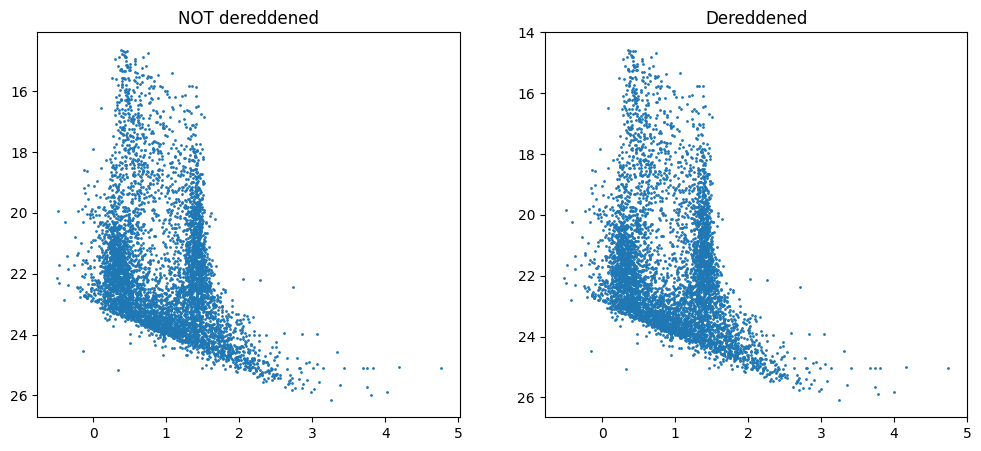

In [6]:
# Plot dereddened vs reddened CMD side by side
plt.figure(figsize=(12,5))

# reddened
plt.subplot(1,2,1)
plt.scatter(df["psfMag_g"]-df["psfMag_r"], df["psfMag_g"], s=1)
plt.gca().invert_yaxis()
plt.title("NOT dereddened")

# dereddened
plt.subplot(1,2,2)
plt.scatter(df["g_r"], df["g0"], s=1)
plt.gca().invert_yaxis()
plt.title("Dereddened")

plt.show()

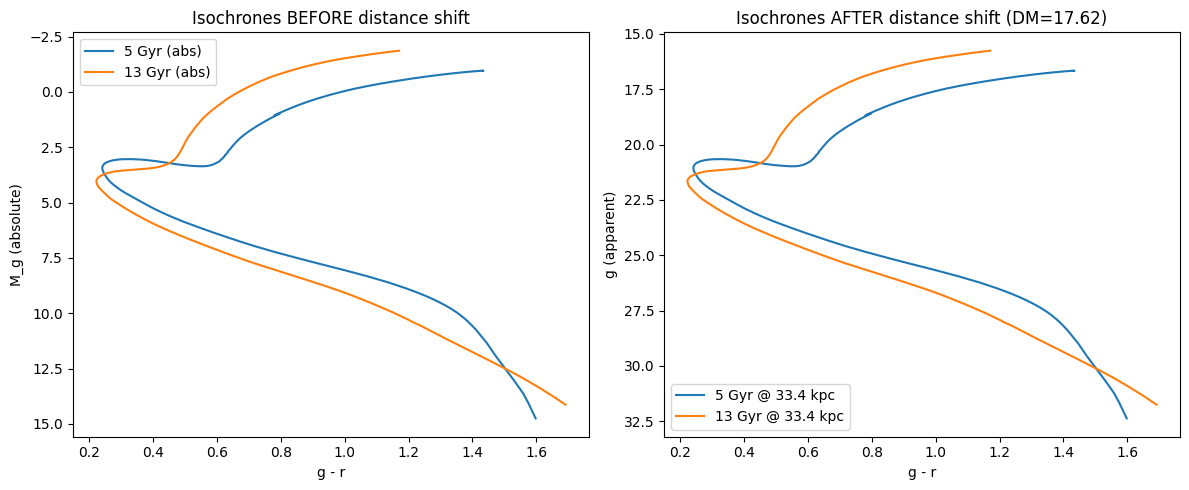

Distance modulus used: DM = 17.6187 mag for d = 33.4 kpc


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Distance modulus for d = 33.4 kpc ---
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)   # ~17.62

def iso_before_after(iso, DM):
    """Return (color_abs, Mg_abs, color_app, g_app) for one isochrone."""
    df_iso = iso.df.copy()

    # BEFORE: absolute magnitudes (intrinsic)
    color_abs = df_iso["sdss_g"] - df_iso["sdss_r"]
    Mg_abs = df_iso["sdss_g"]

    # AFTER: shifted to apparent magnitudes at the Sgr distance
    g_app = df_iso["sdss_g"] + DM
    r_app = df_iso["sdss_r"] + DM
    color_app = g_app - r_app

    return color_abs, Mg_abs, color_app, g_app


c5_abs, g5_abs, c5_app, g5_app = iso_before_after(iso5, DM)
c13_abs, g13_abs, c13_app, g13_app = iso_before_after(iso13, DM)

# --- Plot BEFORE/AFTER for distance correction ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# BEFORE (absolute mags)
ax[0].plot(c5_abs, g5_abs, lw=1.5, label="5 Gyr (abs)")
ax[0].plot(c13_abs, g13_abs, lw=1.5, label="13 Gyr (abs)")
ax[0].invert_yaxis()
ax[0].set_xlabel("g - r")
ax[0].set_ylabel("M_g (absolute)")
ax[0].set_title("Isochrones BEFORE distance shift")
ax[0].legend()

# AFTER (apparent mags at 33.4 kpc)
ax[1].plot(c5_app, g5_app, lw=1.5, label="5 Gyr @ 33.4 kpc")
ax[1].plot(c13_app, g13_app, lw=1.5, label="13 Gyr @ 33.4 kpc")
ax[1].invert_yaxis()
ax[1].set_xlabel("g - r")
ax[1].set_ylabel("g (apparent)")
ax[1].set_title(f"Isochrones AFTER distance shift (DM={DM:.2f})")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Distance modulus used: DM = {DM:.4f} mag for d = {d_pc/1000:.1f} kpc")

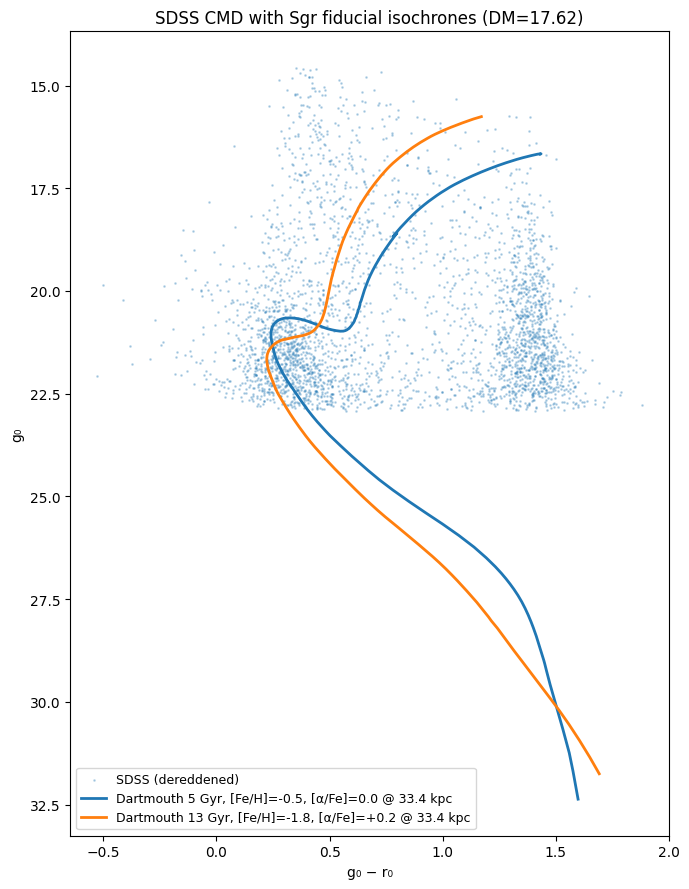

Overlay used DM = 17.6187 mag; SDSS plotted points = 3206 / 5448 (after quality cut)


In [8]:
# --- Overlay dereddened SDSS CMD with distance-shifted Dartmouth isochrones ---
# Distance modulus for Sgr field (33.4 kpc)
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)

# Optional: light quality cut to keep the CMD readable (tweak thresholds as needed)
mask = (
    (df["psfMagErr_g"] < 0.15) &
    (df["psfMagErr_r"] < 0.15) &
    (df["g0"] < 23.5) &
    (df["r0"] < 23.5)
)
d = df[mask].copy()

def shifted_iso(iso, DM):
    """Return (color, mag) arrays for plotting an isochrone shifted to apparent mags."""
    iso_df = iso.df
    g_app = iso_df["sdss_g"] + DM
    r_app = iso_df["sdss_r"] + DM
    color = g_app - r_app
    return color.to_numpy(), g_app.to_numpy()

c5, g5 = shifted_iso(iso5, DM)
c13, g13 = shifted_iso(iso13, DM)

plt.figure(figsize=(7, 9))

# SDSS (dereddened)
plt.scatter(d["g_r"], d["g0"], s=1, alpha=0.25, label="SDSS (dereddened)")

# Isochrones (shifted to 33.4 kpc; no extinction added)
plt.plot(c5, g5, lw=2, label="Dartmouth 5 Gyr, [Fe/H]=-0.5, [α/Fe]=0.0 @ 33.4 kpc")
plt.plot(c13, g13, lw=2, label="Dartmouth 13 Gyr, [Fe/H]=-1.8, [α/Fe]=+0.2 @ 33.4 kpc")

plt.gca().invert_yaxis()
plt.xlabel("g₀ − r₀")
plt.ylabel("g₀")
plt.title(f"SDSS CMD with Sgr fiducial isochrones (DM={DM:.2f})")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Overlay used DM = {DM:.4f} mag; SDSS plotted points = {len(d)} / {len(df)} (after quality cut)")